In [ ]:
# Importação de Bibliotecas

# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para Machine Learning
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate, learning_curve
from sklearn.metrics import mean_absolute_error, r2_score
import time

# Bibliotecas para visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Biblioteca para upload de arquivos no Colab
from google.colab import files

# Instalação do Openpyxl para ler arquivos Excel
!pip install openpyxl -q

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


In [ ]:
# Upload do Pipeline dos Dados de Consumo em .xlsx

print("\nPor favor, faça o upload da base de dados de consumo (formato .xlsx):")
uploaded = files.upload()

if not uploaded:
    print("Falha ao reconhecer arquivo Excel.")
else:
    file_name = next(iter(uploaded))
    print(f"\nArquivo '{file_name}' carregado com sucesso!")


Por favor, faça o upload da base de dados de consumo (formato .xlsx):


Saving consumoEnergiaEletrica_Parametros.xlsx to consumoEnergiaEletrica_Parametros.xlsx

Arquivo 'consumoEnergiaEletrica_Parametros.xlsx' carregado com sucesso!


In [ ]:
# Formatação na leitura dos dados

if 'file_name' in locals():
    print(f"Lendo todos os meses do arquivo '{file_name}'...")

    # sheet_name=None lê todas as abas
    dict_dfs_por_mes = pd.read_excel(file_name, sheet_name=None)
    print(f"Meses encontrados: {list(dict_dfs_por_mes.keys())}")

    # Concatena todos os DataFrames (de todas as abas) em um único
    df_total = pd.concat(dict_dfs_por_mes.values(), ignore_index=True)

    print("\nAbas consolidadas em um único DataFrame.")
    print(f"Total de linhas: {len(df_total)}")

    print("\nVisualização inicial dos dados (primeiras 5 linhas):")
    print(df_total.head())
else:
    print("Falha ao carregar o arquivo Excel.")

Lendo todos os meses do arquivo 'dadosssssss_completos_para_ml.xlsx'...
Meses encontrados: ['MAR24', 'ABR24', 'MAI24', 'JUN24', 'JUL24', 'AGO24', 'SET24', 'OUT24', 'NOV24', 'DEZ24', 'JAN25', 'FEV25', 'MAR25', 'ABR25', 'MAI25', 'JUN25', 'JUL25']

Abas consolidadas em um único DataFrame.
Total de linhas: 74592

Visualização inicial dos dados (primeiras 5 linhas):
            Timestamp  Temperatura Externa  Umidade  booleanDiaUtil  \
0 2024-03-01 00:00:00                   27       84               1   
1 2024-03-01 00:10:00                   27       85               1   
2 2024-03-01 00:20:00                   27       86               1   
3 2024-03-01 00:30:00                   27       86               1   
4 2024-03-01 00:40:00                   27       87               1   

   booleanFeriado  booleanPicoPredio  booleanPicoConcessionaria  \
0               0                  0                          0   
1               0                  0                          0   
2       

In [ ]:
# Pré-Processamento dos Dados

if 'df_total' in locals():
    print("Iniciando processamento dos dados...")

    # Tratamento do Timestamp
    if 'Timestamp' in df_total.columns:
        print("Convertendo coluna 'Timestamp' para índice...")
        df_total['Timestamp'] = pd.to_datetime(df_total['Timestamp'])
        df_total.set_index('Timestamp', inplace=True)
    elif df_total.index.name == 'Timestamp':
        print("O 'Timestamp' já é o índice. Pulando a conversão.")

    df_total.sort_index(inplace=True)

    # Criar uma coluna 'mes' temporária
    df_total['mes_temp'] = df_total.index.month

    # Cálculo do Consumo em formato de Intervalo
    consumo_cols = [col for col in df_total.columns if col.startswith('ConsumokWh_PAV')]
    intervalo_cols = []

    print(f"Calculando consumo intervalar para {len(consumo_cols)} pavimentos...")

    for col in consumo_cols:
        intervalo_col_name = f"Intervalo_{col.split('_')[-1]}"

        # Calcula a diferença (consumo dos últimos 10 min)
        df_total[intervalo_col_name] = df_total[col].diff()

        # Lógicas de Correção

        # Identificação de mudança do mês
        is_new_month = (df_total['mes_temp'].diff() != 0)
        is_month_reset = (df_total[intervalo_col_name] < 0) & (is_new_month)

        # Identificação de falhas nos medidores
        is_glitch = (df_total[intervalo_col_name] < 0) & (~is_new_month)

        # DataFrame atualizado
        df_total.loc[is_month_reset, intervalo_col_name] = df_total[col]

        # Marcar falhas como NaN (Valor Ausente)
        df_total.loc[is_glitch, intervalo_col_name] = np.nan

        intervalo_cols.append(intervalo_col_name)

    # Limpeza Final
    df_total.drop(columns=['mes_temp'], inplace=True)
    df_total[intervalo_cols] = df_total[intervalo_cols].fillna(0)

    # Criação do DataFrame oficial de Consumo Total Real
    df_total['Consumo_Total'] = df_total[intervalo_cols].sum(axis=1)

    print("\nEstatísticas do Consumo Total:")
    print(df_total['Consumo_Total'].describe())

else:
    print("Falha no processamento do Dataframe.")

Iniciando processamento dos dados...
Convertendo coluna 'Timestamp' para índice...
Calculando consumo intervalar para 8 pavimentos...

Estatísticas do Consumo Total:
count    74592.000000
mean        17.590508
std         17.496272
min          0.000000
25%          0.850867
50%         12.301044
75%         33.060317
max        358.200000
Name: Consumo_Total, dtype: float64


In [ ]:
# Engenharia das Features

if 'df_total' in locals() and 'Consumo_Total' in df_total.columns:
    print("Iniciando Engenharia de Features...")

    # Features dos Parâmetros de Economia de Energia
    df_total.rename(columns={
        'Temperatura Externa': 'Temperatura',
        'booleanDiaUtil': 'Dia_Util',
        'booleanFeriado': 'Feriado',
        'booleanPicoPredio': 'Pico_Predio',
        'booleanPicoConcessionaria': 'Pico_Concessionaria'
    }, inplace=True)

    # Features Essenciais de Tempo
    df_total['Hora'] = df_total.index.hour
    df_total['Dia_da_Semana'] = df_total.index.dayofweek
    df_total['Mês'] = df_total.index.month

    # Features de Lag (Memória/Contexto dos Dados)
    df_total['Lag_1hora'] = df_total['Consumo_Total'].shift(6)
    df_total['Lag_1dia'] = df_total['Consumo_Total'].shift(144)

    # [AJUSTE OBRIGATÓRIO - Ponto Fraco 1]
    # Adicionar Baseline 1 (Persistência Simples): Consumo 10 min atrás
    df_total['Lag_10min'] = df_total['Consumo_Total'].shift(1)


    # Definição das Features e do Alvo
    features = [
        'Temperatura', 'Umidade', 'Dia_Util', 'Feriado',
        'Pico_Predio', 'Pico_Concessionaria',
        'Hora', 'Dia_da_Semana', 'Mês',
        'Lag_1hora', 'Lag_1dia',
        'Lag_10min'
    ]
    target = 'Consumo_Total'

    # Limpeza e Separação
    # O .dropna() agora remove os NaNs dos Lags E das falhas (is_glitch)
    df_ml = df_total[features + [target]].dropna()

    X = df_ml[features]
    y = df_ml[target]

    print(f"Features (X) e Alvo (y) definidos com sucesso.")
    print(f"Total de amostras para o Gêmeo Digital: {len(X)}")
    print("\nVisualização das novas features:")
    print(X.head())

else:
    print("Falha na identificação das Features.")

Iniciando Engenharia de Features...
Features (X) e Alvo (y) definidos com sucesso.
Total de amostras para o Gêmeo Digital: 74448

Visualização das novas features:
                     Temperatura  Umidade  Dia_Util  Feriado  Pico_Predio  \
Timestamp                                                                   
2024-03-02 00:00:00           26       89         0        0            0   
2024-03-02 00:10:00           26       87         0        0            0   
2024-03-02 00:20:00           26       86         0        0            0   
2024-03-02 00:30:00           26       84         0        0            0   
2024-03-02 00:40:00           26       82         0        0            0   

                     Pico_Concessionaria  Hora  Dia_da_Semana  Mês  Lag_1hora  \
Timestamp                                                                       
2024-03-02 00:00:00                    0     0              5    3        1.0   
2024-03-02 00:10:00                    0     0        

In [ ]:
# Cálculo dos Baselines

# 1: Persistência Simples
y_pred_b1 = X['Lag_10min']

# Calcular métricas
mae_b1 = mean_absolute_error(y, y_pred_b1)
r2_b1 = r2_score(y, y_pred_b1)

print("\nBaseline 1: Persistência Simples (y_t-1)")
print(f"R² Teste (Baseline 1): {r2_b1:.4f}")
print(f"MAE Teste (Baseline 1): {mae_b1:.4f} kWh")

# Baseline 2: Persistência Sazonal
y_pred_b2 = X['Lag_1dia']

# Calcular métricas
mae_b2 = mean_absolute_error(y, y_pred_b2)
r2_b2 = r2_score(y, y_pred_b2)

print("\n Baseline 2: Persistência Sazonal (y_t-144)")
print(f"R² Teste (Baseline 2): {r2_b2:.4f}")
print(f"MAE Teste (Baseline 2): {mae_b2:.4f} kWh")

features.remove('Lag_10min')
X = X[features]


Baseline 1: Persistência Simples (y_t-1)
R² Teste (Baseline 1): 0.9781
MAE Teste (Baseline 1): 0.7439 kWh

 Baseline 2: Persistência Sazonal (y_t-144)
R² Teste (Baseline 2): 0.2082
MAE Teste (Baseline 2): 8.5147 kWh


In [ ]:
# Treinamento do Gêmeo Digital com LinearRegression

if 'X' in locals() and 'y' in locals():
    print("Iniciando Validação do Gêmeo Digital (LinearRegression)...\n")
    print(f"Features utilizadas: {X.columns.to_list()}")

    # Criação do Pipeline com StandardScaler
    lr_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ])

    # Definição do TimeSeriesSplit
    time_series_cv = TimeSeriesSplit(n_splits=5)

    scoring_metrics = ['r2', 'neg_mean_absolute_error']
    print("Iniciando Validação Cruzada com TimeSeriesSplit para Treino e Teste...")
    start_time = time.time()

    cv_results = cross_validate(
        lr_pipeline, X, y,
        cv=time_series_cv,
        scoring=scoring_metrics,
        return_train_score=True,
        n_jobs=-1
    )
    end_time = time.time()
    print(f"Validação concluída em {end_time - start_time:.1f} segundos.")

    print("\n    R² e MAE da Regressão Linear:")

    # Métricas de Treino
    r2_treino_mean = cv_results['train_r2'].mean()
    r2_treino_std = cv_results['train_r2'].std()
    mae_treino_mean = -cv_results['train_neg_mean_absolute_error'].mean()
    mae_treino_std = cv_results['train_neg_mean_absolute_error'].std()

    # Métricas de Teste
    r2_teste_mean = cv_results['test_r2'].mean()
    r2_teste_std = cv_results['test_r2'].std()
    mae_teste_mean = -cv_results['test_neg_mean_absolute_error'].mean()
    mae_teste_std = cv_results['test_neg_mean_absolute_error'].std()

    print("\nMétricas de Treino:")
    print(f"R² Treino:     {r2_treino_mean:.4f} (std: {r2_treino_std:.4f})")
    print(f"MAE Treino (kWh): {mae_treino_mean:.4f} (std: {mae_treino_std:.4f})")

    print("\nMétricas de Teste:")
    print(f"R² Teste:      {r2_teste_mean:.4f} (std: {r2_teste_std:.4f})")
    print(f"MAE Teste (kWh):  {mae_teste_mean:.4f} (std: {mae_teste_std:.4f})")

    print("\n    Diagnóstico    ")
    if abs(r2_treino_mean - r2_teste_mean) < 0.1:
        print("Overfitting não detectado. Modelo bem ajustado.")
    else:
        print("Overfitting DETECTADO.")

    # Treino Final do Modelo Preditivo
    print("\nTreinando o Gêmeo Digital com Regressão Linear...")
    modelo_final = lr_pipeline.fit(X, y)
    print("Gêmeo Digital treinado com sucesso.")

else:
    print("Falha na validação do Modelo Preditivo.")

Iniciando Validação do Gêmeo Digital (LinearRegression)...

Features utilizadas: ['Temperatura', 'Umidade', 'Dia_Util', 'Feriado', 'Pico_Predio', 'Pico_Concessionaria', 'Hora', 'Dia_da_Semana', 'Mês', 'Lag_1hora', 'Lag_1dia']
Iniciando Validação Cruzada com TimeSeriesSplit para Treino e Teste...
Validação concluída em 2.7 segundos.

    R² e MAE da Regressão Linear:

Métricas de Treino:
R² Treino:     0.8876 (std: 0.0129)
MAE Treino (kWh): 4.0847 (std: 0.6511)

Métricas de Teste:
R² Teste:      0.9037 (std: 0.0292)
MAE Teste (kWh):  2.9982 (std: 0.8083)

    Diagnóstico    
Overfitting não detectado. Modelo bem ajustado.

Treinando o Gêmeo Digital com Regressão Linear...
Gêmeo Digital treinado com sucesso.


Iniciando Análise de Resíduos do Modelo Final...


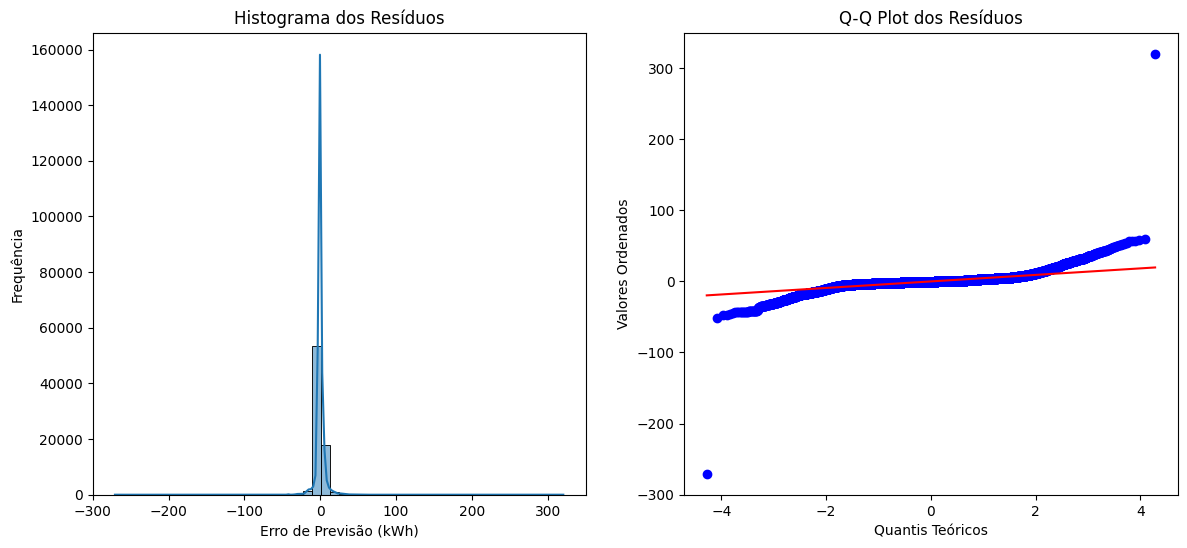

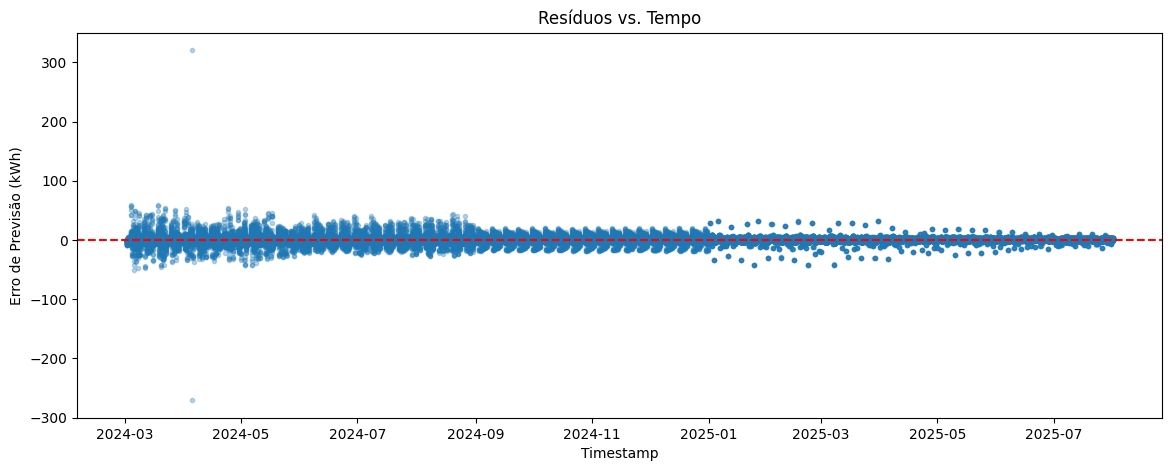

Análise de Autocorrelação dos Resíduos (ACF e PACF):


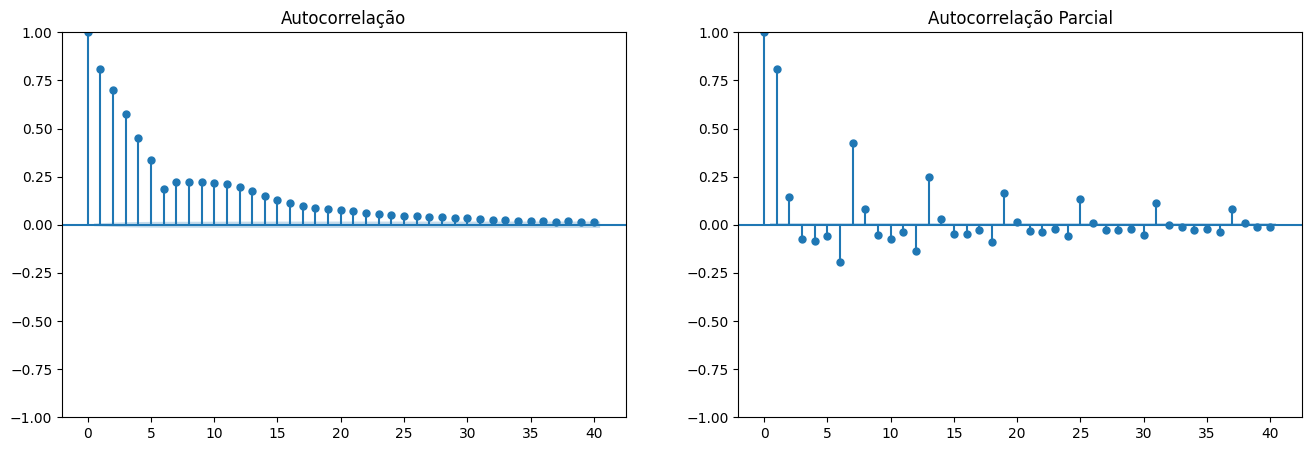

In [ ]:
# Análise Diagnóstica de Resíduos

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats

print("Iniciando Análise de Resíduos do Modelo Final...")

# Calcular predições e resíduos
try:
    y_predito_final = modelo_final.predict(X)
    residuos = y - y_predito_final

    # 2. Histograma e Q-Q Plot
    plt.figure(figsize=(14, 6))

    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(residuos, kde=True, bins=50)
    plt.title('Histograma dos Resíduos')
    plt.xlabel('Erro de Previsão (kWh)')
    plt.ylabel('Frequência')  # <-- EIXO TRADUZIDO

    # Q-Q Plot
    plt.subplot(1, 2, 2)
    stats.probplot(residuos, dist="norm", plot=plt)
    plt.title('Q-Q Plot dos Resíduos')
    plt.xlabel('Quantis Teóricos')    # <-- EIXO TRADUZIDO
    plt.ylabel('Valores Ordenados') # <-- EIXO TRADUZIDO

    plt.savefig("histograma_e_qqplot_residuos.png") # <-- CORREÇÃO: Salvar antes de mostrar
    plt.show()


    # 3. Gráfico de Resíduos vs. Tempo (Verificar Heterocedasticidade)
    plt.figure(figsize=(14, 5))
    plt.plot(X.index, residuos, '.', alpha=0.3)
    plt.title('Resíduos vs. Tempo')
    plt.xlabel('Timestamp')
    plt.ylabel('Erro de Previsão (kWh)')
    plt.axhline(y=0, color='r', linestyle='--')

    plt.savefig("residuos_vs_tempo.png") # <-- CORREÇÃO: Salvar antes de mostrar
    plt.show()


    # 4. Gráficos ACF e PACF (Verificar Autocorrelação)
    print("Análise de Autocorrelação dos Resíduos (ACF e PACF):")
    fig, ax = plt.subplots(1, 2, figsize=(16, 5))

    plot_acf(residuos, lags=40, ax=ax[0])
    ax[0].set_title('Autocorrelação') # <-- TÍTULO TRADUZIDO

    plot_pacf(residuos, lags=40, ax=ax[1])
    ax[1].set_title('Autocorrelação Parcial') # <-- TÍTULO TRADUZIDO

    plt.savefig("acf_pacf_residuos.png") # <-- CORREÇÃO: Salvar antes de mostrar
    plt.show()


except NameError:
    print("Erro: 'modelo_final' ou 'X'/'y' não encontrados. Rode a Célula 8 primeiro.")
except Exception as e:
    print(f"Ocorreu um erro na análise de resíduos: {e}")

Gerando a Curva de Aprendizado para o Gêmeo Digital...


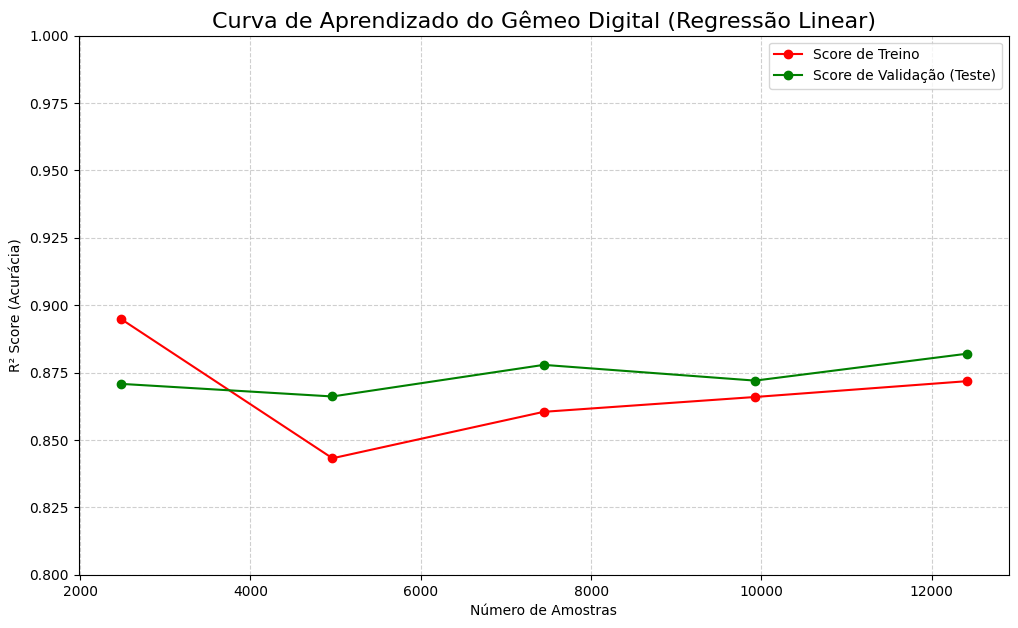

In [ ]:
# Curva de Aprendizado

if 'X' in locals() and 'y' in locals() and 'lr_pipeline' in locals():
    print("Gerando a Curva de Aprendizado para o Gêmeo Digital...")

    # Validação Temporal
    tscv_curve = TimeSeriesSplit(n_splits=5)

    # Cálculo dos Scores das curvas
    train_sizes_abs, train_scores, test_scores = learning_curve(
        lr_pipeline,
        X,
        y,
        cv=tscv_curve,
        n_jobs=-1,
        scoring='r2',
        train_sizes=np.linspace(0.2, 1.0, 5)
    )

    # Cálculo das médias
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    # Plotar o gráfico
    plt.figure(figsize=(12, 7))
    plt.title('Curva de Aprendizado do Gêmeo Digital (Regressão Linear)', fontsize=16)
    plt.xlabel('Número de Amostras')
    plt.ylabel('R² Score (Acurácia)')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Plotar as linhas de média
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color="r",
             label="Score de Treino")
    plt.plot(train_sizes_abs, test_scores_mean, 'o-', color="g",
             label="Score de Validação (Teste)")

    plt.legend(loc="best")
    plt.ylim(0.8, 1)
    plt.show()

else:
    print("Falha ao gerar Curva de Aprendizado.")

Inspecionando os Coeficientes do Gêmeo Digital...

       Análise de Coeficientes do Modelo Preditivo
                Feature  Coeficiente (Peso)  Importancia
9             Lag_1hora           14.973776    14.973776
10             Lag_1dia            1.740636     1.740636
5   Pico_Concessionaria           -1.325092     1.325092
7         Dia_da_Semana           -0.971438     0.971438
1               Umidade            0.428606     0.428606
3               Feriado           -0.277212     0.277212
6                  Hora           -0.263448     0.263448
2              Dia_Util            0.259538     0.259538
4           Pico_Predio           -0.085435     0.085435
8                   Mês           -0.081229     0.081229
0           Temperatura           -0.029400     0.029400


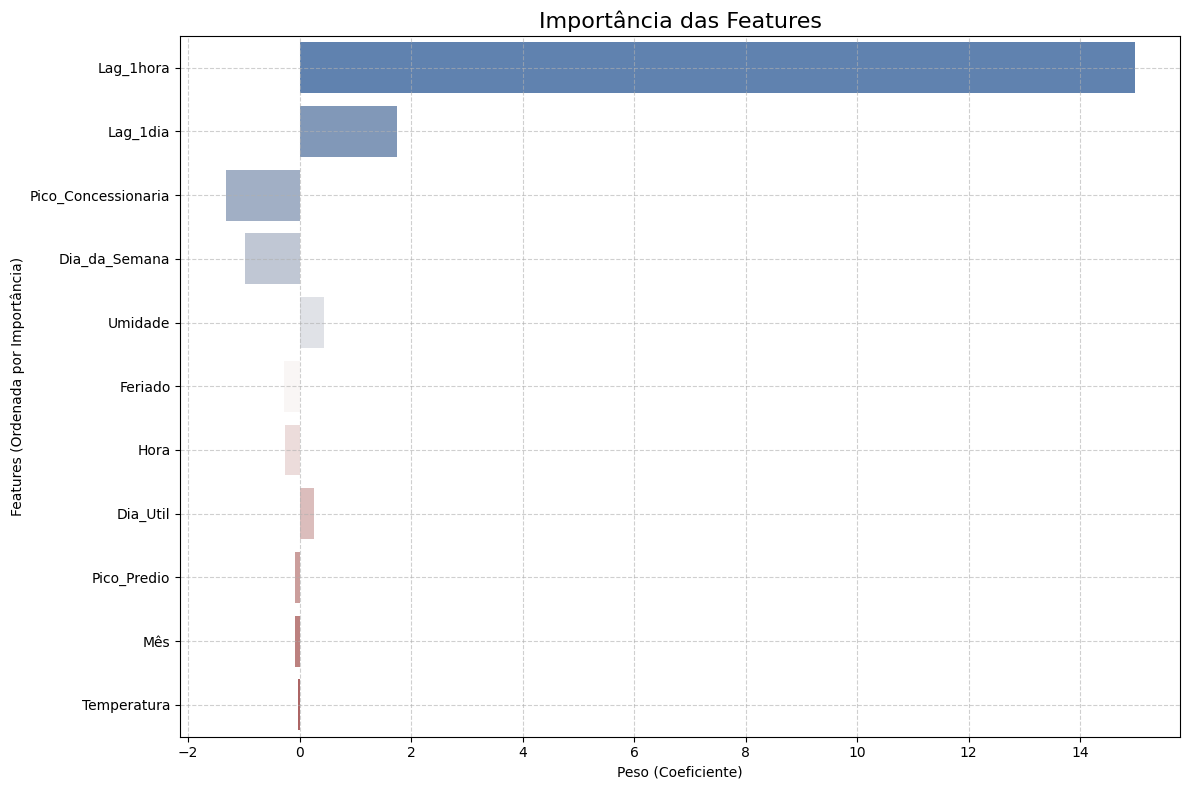

In [ ]:
# Análise de Coeficientes e Importância das Features

if 'modelo_final' in locals() and 'X' in locals():
    print("Inspecionando os Coeficientes do Gêmeo Digital...")

    # Extração dos coeficientes do pipeline
    try:
        coeficientes = modelo_final.named_steps['model'].coef_
        feature_names = X.columns

        # Criação de DataFrame para Análise de Coeficientes
        df_coeficientes = pd.DataFrame({
            'Feature': feature_names,
            'Coeficiente (Peso)': coeficientes
        })

        # Criar coluna de importância (peso) para ordenar o gráfico
        df_coeficientes['Importancia'] = df_coeficientes['Coeficiente (Peso)'].abs()
        df_coeficientes = df_coeficientes.sort_values(by='Importancia', ascending=False)

        print("\n       Análise de Coeficientes do Modelo Preditivo")
        print(df_coeficientes)

        # 3. Plotar a importância
        plt.figure(figsize=(12, 8))
        sns.barplot(
            x='Coeficiente (Peso)',
            y='Feature',
            data=df_coeficientes,
            palette='vlag',
            hue='Feature',
            legend=False
        )
        plt.title('Importância das Features', fontsize=16)
        plt.xlabel('Peso (Coeficiente)')
        plt.ylabel('Features (Ordenada por Importância)')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Erro ao extrair coeficientes: {e}")

else:
    print("Falhar ao gerar Análise de Coeficiente.")

Gerando Matriz de Correlação...


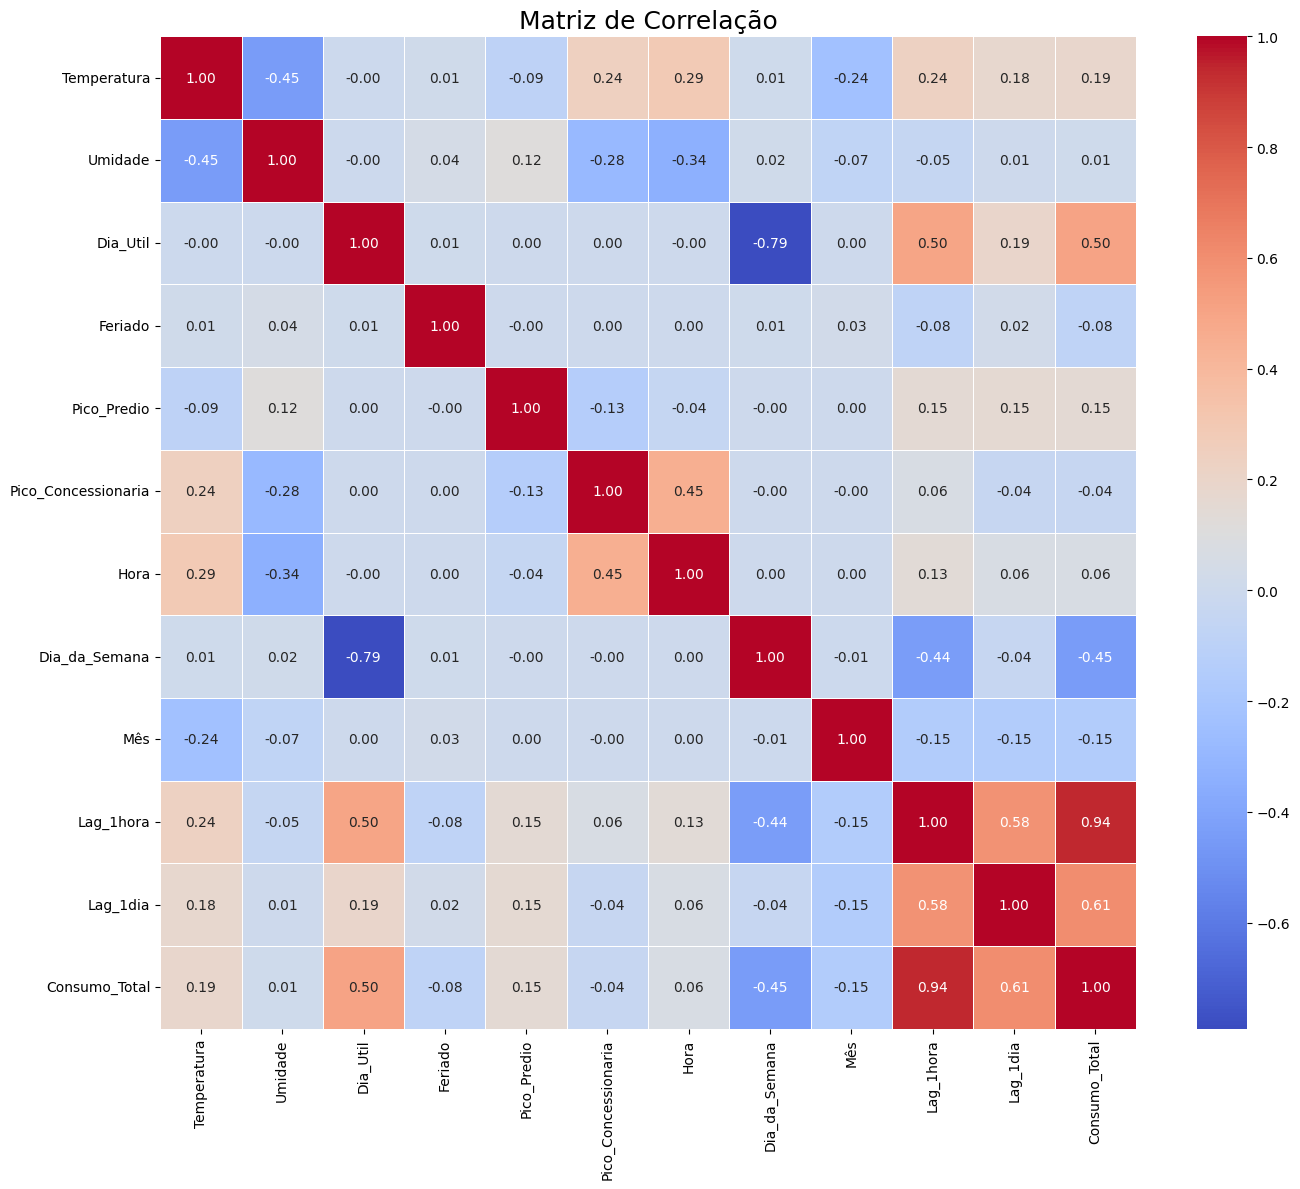

In [ ]:
# Matriz de Correlação

if 'X' in locals() and 'y' in locals():
    print("Gerando Matriz de Correlação...")

    df_correlacao = X.join(y)
    correlacao_matrix = df_correlacao.corr()

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        correlacao_matrix,
        annot=True,     # Mostra os números
        fmt='.2f',      # Formato com 2 casas decimais
        cmap='coolwarm', # Esquema de cores de Heatmap
        linewidths=0.5
    )
    plt.title('Matriz de Correlação', fontsize=18)
    plt.tight_layout()
    plt.show()

else:
    print("Falha ao gear Matriz de Correlação.")

In [ ]:
# Simulação do Cenário Otimizado

if 'df_total' in locals() and 'Consumo_Total' in df_total.columns:
    print("Iniciando Análise de Sensibilidade (Múltiplos Cenários)...\n")

    # 1. Definir Cenários de Redução (Conforme sugestão do orientador)
    cenarios_reducao_percentual = [0.10, 0.20, 0.27, 0.35] # 10%, 20%, 27%, 35%

    # Armazenar resultados
    resultados_simulacao = []

    # DataFrame base para simulações
    df_simulacao = df_total.copy()

    # Condição de Pico (onde a regra se aplica)
    # (Corrigindo a janela de 17h-21h, conforme Ponto Fraco 4)
    condicao_pico = (df_simulacao['Pico_Concessionaria'] == 1)
    print(f"Registros encontrados no horário de pico (17h-21h): {condicao_pico.sum()}")

    # Calcular Consumo Real Total (só precisa fazer uma vez)
    total_real_kwh = df_simulacao['Consumo_Total'].sum()
    print(f"Consumo Real Total (Período): {total_real_kwh:,.2f} kWh\n")

    # --- Loop pelos Cenários ---
    for percentual in cenarios_reducao_percentual:
        print(f"--- Simulando Cenário: Redução de {percentual*100:.0f}% ---")

        multiplicador_reducao = 1 - percentual

        # Criar coluna simulada para este cenário (começa igual ao real)
        coluna_cenario = f'Simulado_{percentual*100:.0f}pct'
        df_simulacao[coluna_cenario] = df_simulacao['Consumo_Total']

        # Aplicar a regra de redução APENAS no pico
        df_simulacao.loc[condicao_pico, coluna_cenario] = \
            df_simulacao.loc[condicao_pico, coluna_cenario] * multiplicador_reducao

        # Calcular resultados deste cenário
        total_simulado_kwh = df_simulacao[coluna_cenario].sum()
        economia_kwh = total_real_kwh - total_simulado_kwh
        economia_percentual = (economia_kwh / total_real_kwh) * 100

        # Guardar resultados
        resultados_simulacao.append({
            'Cenário de Redução': f"{percentual*100:.0f}%",
            'Consumo Simulado (kWh)': total_simulado_kwh,
            'Economia (kWh)': economia_kwh,
            'Economia (%)': economia_percentual
        })

        print(f"Consumo Simulado: {total_simulado_kwh:,.2f} kWh")
        print(f"Economia Gerada: {economia_kwh:,.2f} kWh ({economia_percentual:.2f}%)")
        print("-" * 30)

    # 3. Exibir tabela comparativa dos cenários
    df_resultados_finais_energia = pd.DataFrame(resultados_simulacao)
    print("\n=== RESULTADO DA ANÁLISE DE SENSIBILIDADE (ENERGIA) ===")
    print(df_resultados_finais_energia.to_string(float_format="%.2f"))

else:
    print("Falha ao realizar simulação (df_total não encontrado).")

Iniciando Análise de Sensibilidade (Múltiplos Cenários)...

Registros encontrados no horário de pico (17h-21h): 12432
Consumo Real Total (Período): 1,312,111.14 kWh

--- Simulando Cenário: Redução de 10% ---
Consumo Simulado: 1,292,174.76 kWh
Economia Gerada: 19,936.38 kWh (1.52%)
------------------------------
--- Simulando Cenário: Redução de 20% ---
Consumo Simulado: 1,272,238.38 kWh
Economia Gerada: 39,872.76 kWh (3.04%)
------------------------------
--- Simulando Cenário: Redução de 27% ---
Consumo Simulado: 1,258,282.91 kWh
Economia Gerada: 53,828.22 kWh (4.10%)
------------------------------
--- Simulando Cenário: Redução de 35% ---
Consumo Simulado: 1,242,333.81 kWh
Economia Gerada: 69,777.33 kWh (5.32%)
------------------------------

=== RESULTADO DA ANÁLISE DE SENSIBILIDADE (ENERGIA) ===
  Cenário de Redução  Consumo Simulado (kWh)  Economia (kWh)  Economia (%)
0                10%              1292174.76        19936.38          1.52
1                20%              12722

In [ ]:
# Análise de Resultados Financeiros

import pandas as pd
from IPython.display import display

if 'df_simulacao' in locals() and 'cenarios_reducao_percentual' in locals() \
   and 'df_resultados_finais_energia' in locals() and 'total_real_kwh' in locals():

    print("Iniciando Análise de Resultados Financeiros da Simulação...\n")

    try:
        cenario_principal = df_resultados_finais_energia[
            df_resultados_finais_energia['Cenário de Redução'] == '27%'
        ].iloc[0]

        print("     Resultados do Cenário Principal (Redução de 27%)     ")
        print(f"Período de Análise: {df_simulacao.index.min().date()} até {df_simulacao.index.max().date()}")
        print(f"Consumo Real Total:        {total_real_kwh:,.2f} kWh")
        print(f"Consumo Simulado (27%):    {cenario_principal['Consumo Simulado (kWh)']:,.2f} kWh")
        print(f"Economia Total (27%):      {cenario_principal['Economia (kWh)']:,.2f} kWh")
        print(f"Economia Percentual (27%): {cenario_principal['Economia (%)']:.2f} %")

    except Exception as e:
        print(f"Não foi possível extrair o cenário principal (27%): {e}")

    TARIFA_PICO = 4.40
    TARIFA_FORA_PICO = 0.39

    print("\n     Análise Financeira (Baseada nos Cenários)     ")
    print(f"Tarifa Pico:      R$ {TARIFA_PICO:.2f}/kWh")
    print(f"Tarifa Fora-Pico: R$ {TARIFA_FORA_PICO:.2f}/kWh")

    condicao_pico = (df_simulacao['Pico_Concessionaria'] == 1)

    # Custo Real
    df_simulacao['Custo_Real'] = df_simulacao['Consumo_Total'] * TARIFA_FORA_PICO
    df_simulacao.loc[condicao_pico, 'Custo_Real'] = \
        df_simulacao.loc[condicao_pico, 'Consumo_Total'] * TARIFA_PICO

    custo_total_real = df_simulacao['Custo_Real'].sum()

    resultados_financeiros = []
    num_meses = (df_simulacao.index.max() - df_simulacao.index.min()).days / 30.4

    for percentual in cenarios_reducao_percentual:
        coluna_consumo = f'Simulado_{percentual*100:.0f}pct'
        coluna_custo   = f'Custo_{percentual*100:.0f}pct'

        # Custo simulado
        df_simulacao[coluna_custo] = df_simulacao[coluna_consumo] * TARIFA_FORA_PICO
        df_simulacao.loc[condicao_pico, coluna_custo] = \
            df_simulacao.loc[condicao_pico, coluna_consumo] * TARIFA_PICO

        custo_simulado = df_simulacao[coluna_custo].sum()
        economia_reais = custo_total_real - custo_simulado

        resultados_financeiros.append({
            'Cenário de Redução': f"{percentual*100:.0f}%",
            'Custo Simulado (R$)': custo_simulado,
            'Economia Total (R$)': economia_reais,
            'Economia Média (R$/mês)': economia_reais / num_meses
        })

    print("\n     Resultados da Simulação (Custo Real)   ")
    print(f"Custo Real Total (no período): R$ {custo_total_real:,.2f}")

    titulo_tabela = "Resultado da Análise de Sensibilidade (Financeira)"

    df_resultados_financeiros = pd.DataFrame(resultados_financeiros)

    # Formatação
    format_dict = {
        'Custo Simulado (R$)': 'R$ {:,.2f}',
        'Economia Total (R$)': 'R$ {:,.2f}',
        'Economia Média (R$/mês)': 'R$ {:,.2f}'
    }

    tabela_formatada = (
        df_resultados_financeiros
        .style
        .format(format_dict)
        .hide(axis="index")
        .set_caption(titulo_tabela)
    )

    display(tabela_formatada)

else:
    print("Falha na execução: Variáveis essenciais não foram encontradas.")
    print("Execute as células anteriores antes de rodar esta.")


Iniciando Análise de Resultados Financeiros da Simulação...

     Resultados do Cenário Principal (Redução de 27%)     
Período de Análise: 2024-03-01 até 2025-07-31
Consumo Real Total:        1,312,111.14 kWh
Consumo Simulado (27%):    1,258,282.91 kWh
Economia Total (27%):      53,828.22 kWh
Economia Percentual (27%): 4.10 %

     Análise Financeira (Baseada nos Cenários)     
Tarifa Pico:      R$ 4.40/kWh
Tarifa Fora-Pico: R$ 0.39/kWh

     Resultados da Simulação (Custo Real)   
Custo Real Total (no período): R$ 1,311,172.14


Cenário de Redução,Custo Simulado (R$),Economia Total (R$),Economia Média (R$/mês)
10%,"R$ 1,223,452.07","R$ 87,720.07","R$ 5,158.01"
20%,"R$ 1,135,732.01","R$ 175,440.14","R$ 10,316.02"
27%,"R$ 1,074,327.96","R$ 236,844.18","R$ 13,926.62"
35%,"R$ 1,004,151.90","R$ 307,020.24","R$ 18,053.03"


In [ ]:
# Consolidação dos Resultados (Energia + Financeiro)

import locale
from IPython.display import display

df_simulacao = df_total.copy()

condicao_pico = (df_simulacao['Pico_Concessionaria'] == 1)
print(f"Registros encontrados no Horário de Pico da Concessionária (17h-21h): {condicao_pico.sum()}")

def fmt_brl_num(valor):
    try:
        formatted_str = "{:,.2f}".format(valor)
        parts = formatted_str.split('.')
        decimal_part = parts[-1]
        integer_part = '.'.join(parts[:-1])
        integer_part = integer_part.replace(',', '.')

        return f"{integer_part},{decimal_part}"
    except (ValueError, TypeError):
        return valor

def fmt_brl_moeda(valor):
    try:
        formatted_str = "{:,.2f}".format(valor)
        parts = formatted_str.split('.')
        decimal_part = parts[-1]
        integer_part = '.'.join(parts[:-1])
        integer_part = integer_part.replace(',', '.')
        return f"R$ {integer_part},{decimal_part}"
    except (ValueError, TypeError):
        return valor

if ('df_resultados_finais_energia' in locals() and
    'df_resultados_financeiros' in locals()):

    print("\nGerando Resultados da Simulação Preditiva...\n")

    df_resultados_finais_energia["Cenário de Redução"] = (
        df_resultados_finais_energia["Cenário de Redução"]
        .astype(str)
        .str.replace(".0", "")
        .str.replace("%", "")
        + "%"
    )

    df_resultados_financeiros["Cenário de Redução"] = (
        df_resultados_financeiros["Cenário de Redução"]
        .astype(str)
        .str.replace(".0", "")
        .str.replace("%", "")
        + "%"
    )

    df_consolidada = df_resultados_finais_energia.merge(
        df_resultados_financeiros,
        on="Cenário de Redução",
        how="inner"
    )

    format_dict = {
        'Consumo Simulado (kWh)': fmt_brl_num,
        'Economia (kWh)': fmt_brl_num,
        'Economia (%)': fmt_brl_num,
        'Custo Simulado (R$)': fmt_brl_moeda,
        'Economia Total (R$)': fmt_brl_moeda,
        'Economia Média (R$/mês)': fmt_brl_moeda,
    }

    tabela_formatada = df_consolidada.style.format(format_dict).hide(axis="index")
    display(tabela_formatada)

else:
    print("Erro: As tabelas df_resultados_finais_energia e df_resultados_financeiros não foram encontradas.")
    print("Execute antes as células de análise de energia e financeira.")


Registros encontrados no Horário de Pico da Concessionária (17h-21h): 12432

Gerando Resultados da Simulação Preditiva...



Cenário de Redução,Consumo Simulado (kWh),Economia (kWh),Economia (%),Custo Simulado (R$),Economia Total (R$),Economia Média (R$/mês)
10%,"1.292.174,76","19.936,38","1,52","R$ 1.223.452,07","R$ 87.720,07","R$ 5.158,01"
20%,"1.272.238,38","39.872,76","3,04","R$ 1.135.732,01","R$ 175.440,14","R$ 10.316,02"
27%,"1.258.282,91","53.828,22","4,10","R$ 1.074.327,96","R$ 236.844,18","R$ 13.926,62"
35%,"1.242.333,81","69.777,33","5,32","R$ 1.004.151,90","R$ 307.020,24","R$ 18.053,03"
